# Fixed-Point GEMM Error & Determinism

Compare the element-wise relative error of matrix multiplication (C = A @ B) across:

**Floating-point baselines:**
- **fp16** matmul (`torch.matmul` in fp16)
- **bf16** matmul (`torch.matmul` in bf16)
- **fp32** matmul (`torch.matmul` in fp32)

**Fixed-point kernel:**
- Current Triton fixed-point GEMM configuration (kernel-internal fractional bits and accumulator type)

Ground truth is `torch.matmul` in fp64. Each point is the **median** of the per-element median relative error over 50 trials.

In [7]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../tests"))

import numpy as np
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt

from triton_vllm_fixed_point_reductions.fixed_point_kernels import gemm

In [8]:
# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------


def run_fp_gemm(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """Launch the fixed-point GEMM Triton kernel."""
    M, K = a.shape
    _, N = b.shape
    c = torch.empty((M, N), device=a.device, dtype=torch.float32)

    BLOCK_M = triton.next_power_of_2(max(M, 1))
    BLOCK_N = triton.next_power_of_2(max(N, 1))
    BLOCK_K = triton.next_power_of_2(max(K, 1))

    grid = (triton.cdiv(M, BLOCK_M), triton.cdiv(N, BLOCK_N))
    gemm.gemm_fp_kernel[grid](
        a,
        b,
        c,
        M,
        N,
        K,
        a.stride(0),
        a.stride(1),
        b.stride(0),
        b.stride(1),
        c.stride(0),
        c.stride(1),
        BLOCK_SIZE_M=BLOCK_M,
        BLOCK_SIZE_N=BLOCK_N,
        BLOCK_SIZE_K=BLOCK_K,
    )
    return c


def ground_truth(a, b):
    """fp64 matmul as reference."""
    return torch.matmul(a.to(torch.float64), b.to(torch.float64))


def elementwise_rel_error(got, ref):
    """Median per-element relative error (ignoring zeros in ref)."""
    ref64 = ref.to(torch.float64)
    got64 = got.to(torch.float64)
    mask = ref64.abs() > 0
    if mask.sum() == 0:
        return 0.0
    err = (got64[mask] - ref64[mask]).abs() / ref64[mask].abs()
    return err.median().item()


# ── method definitions: (label, function, family, bitwidth) ──────────
M_FIX, N_FIX = 8, 8  # fix M, N; sweep K
K_SIZES = [16, 32, 64, 128, 256, 512, 1024]
N_TRIALS = 50

METHODS = [
    # --- floating-point baselines ---
    ("fp16 matmul", lambda a, b: torch.matmul(a.half(), b.half()).float(), "fp", 16),
    ("fp32 matmul", lambda a, b: torch.matmul(a, b), "fp", 32),
    (
        "fp64 matmul",
        lambda a, b: torch.matmul(a.double(), b.double()).float(),
        "fp",
        64,
    ),
    # --- fixed-point kernel (configuration is internal to kernel) ---
    ("fixed-point kernel", lambda a, b: run_fp_gemm(a, b), "fx", 32),
]

# ── same colour for matching bitwidths, dashed for fixed-point ───────
FAMILY_STYLE = {"fp": "-", "fx": "--"}
BITWIDTH_COLORS = {16: "#e41a1c", 32: "#377eb8", 64: "#4daf4a"}

In [9]:
def run_error_benchmark(configs, suptitle):
    """Plot median relative error vs K for each distribution config."""
    n = len(configs)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, (name, sample_fn) in zip(axes, configs):
        medians = {label: [] for label, _, _, _ in METHODS}

        for K in K_SIZES:
            trial_errors = {label: [] for label, _, _, _ in METHODS}

            for _ in range(N_TRIALS):
                a, b = sample_fn(M_FIX, K, N_FIX)
                ref = ground_truth(a, b)

                for label, fn, _, _ in METHODS:
                    got = fn(a, b)
                    trial_errors[label].append(elementwise_rel_error(got, ref))

            for label, _, _, _ in METHODS:
                medians[label].append(np.median(trial_errors[label]))

        line_labels = []
        for label, _, family, bw in METHODS:
            ax.plot(
                K_SIZES,
                medians[label],
                linestyle=FAMILY_STYLE[family],
                color=BITWIDTH_COLORS[bw],
                marker="o",
                markersize=4,
            )
            line_labels.append((label, BITWIDTH_COLORS[bw], medians[label][-1]))

        ax.set_xscale("log", base=2)
        ax.set_yscale("symlog", linthresh=1e-16)
        ax.set_xlim(K_SIZES[0], K_SIZES[-1] * 2.0)
        ax.set_xlabel("K (reduction dimension)")
        ax.set_title(name)
        ax.grid(True, alpha=0.2)

        for label, color, y in sorted(line_labels, key=lambda item: item[2]):
            ax.text(
                K_SIZES[-1] * 1.15,
                y,
                label,
                color=color,
                fontsize=8,
                va="center",
                ha="left",
                clip_on=False,
            )

    axes[0].set_ylabel("Median element-wise relative error")
    fig.suptitle(suptitle, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## Normal distributions

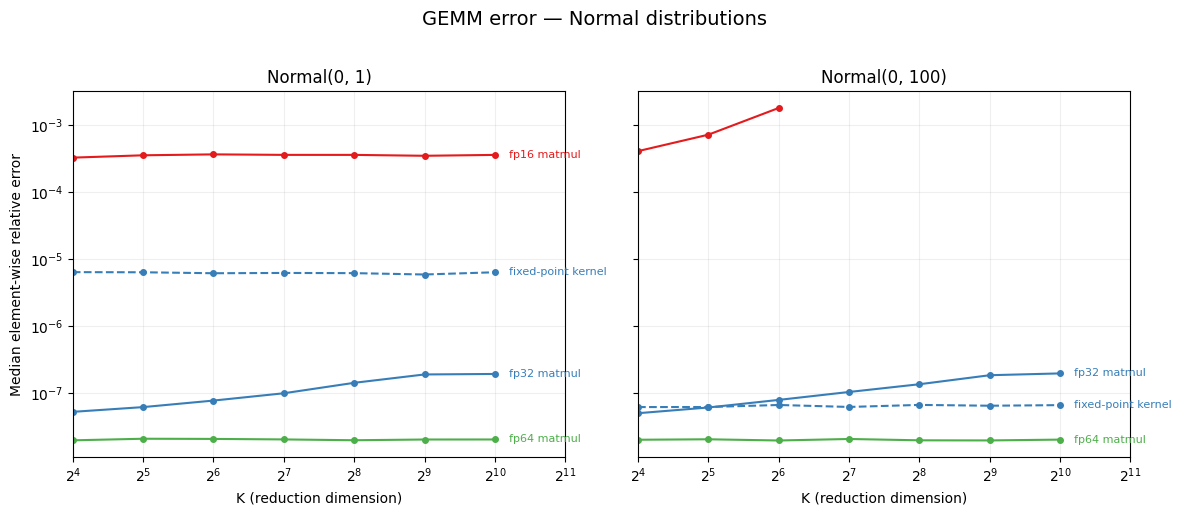

In [10]:
normal_configs = [
    (
        "Normal(0, 1)",
        lambda M, K, N: (
            torch.randn(M, K, device="cuda", dtype=torch.float32),
            torch.randn(K, N, device="cuda", dtype=torch.float32),
        ),
    ),
    (
        "Normal(0, 100)",
        lambda M, K, N: (
            torch.randn(M, K, device="cuda", dtype=torch.float32) * 100,
            torch.randn(K, N, device="cuda", dtype=torch.float32) * 100,
        ),
    ),
]

run_error_benchmark(normal_configs, "GEMM error — Normal distributions")

## Uniform distributions

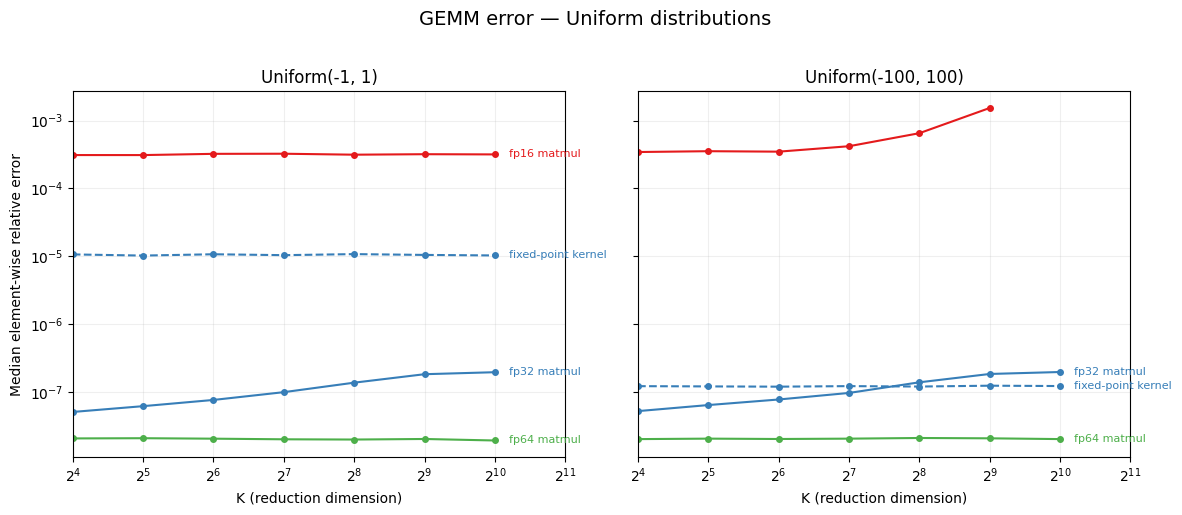

In [11]:
uniform_configs = [
    (
        "Uniform(-1, 1)",
        lambda M, K, N: (
            torch.empty(M, K, device="cuda", dtype=torch.float32).uniform_(-1, 1),
            torch.empty(K, N, device="cuda", dtype=torch.float32).uniform_(-1, 1),
        ),
    ),
    (
        "Uniform(-100, 100)",
        lambda M, K, N: (
            torch.empty(M, K, device="cuda", dtype=torch.float32).uniform_(-100, 100),
            torch.empty(K, N, device="cuda", dtype=torch.float32).uniform_(-100, 100),
        ),
    ),
]

run_error_benchmark(uniform_configs, "GEMM error — Uniform distributions")

## Determinism: K-permutation invariance

For each K size, we randomly permute the K-dimension of A and B and check whether the result changes. Float matmul can produce different bits; the fixed-point kernel must always match exactly.

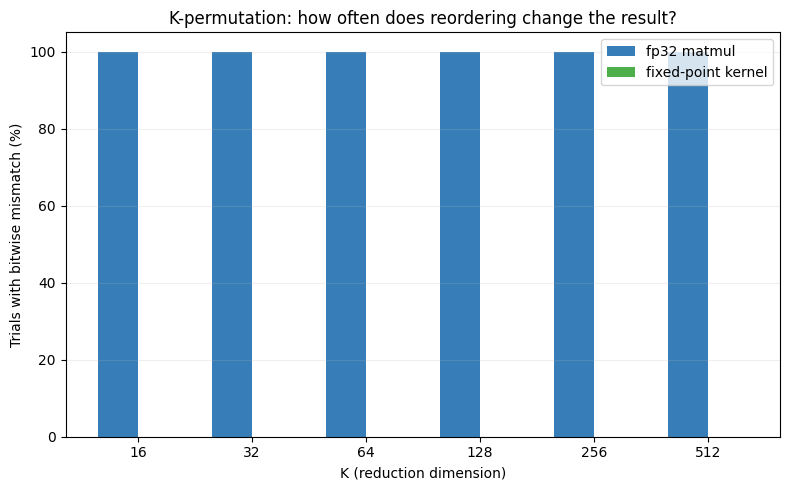

fp32 mismatch rates: [100.0, 100.0, 100.0, 100.0, 100.0, 100.0]
fxp  mismatch rates: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [12]:
DET_K_SIZES = [16, 32, 64, 128, 256, 512]
DET_TRIALS = 20
M_DET, N_DET = 8, 8

fp32_mismatches = []
fxp_mismatches = []

for K in DET_K_SIZES:
    fp32_count = 0
    fxp_count = 0

    for _ in range(DET_TRIALS):
        a = (torch.randn(M_DET, K, device="cuda", dtype=torch.float32)) * 10.0
        b = (torch.randn(K, N_DET, device="cuda", dtype=torch.float32)) * 10.0

        perm = torch.randperm(K, device="cuda")
        a_p = a[:, perm]
        b_p = b[perm, :]

        # fp32 matmul
        c_orig = torch.matmul(a, b)
        c_perm = torch.matmul(a_p, b_p)
        if not torch.equal(c_orig, c_perm):
            fp32_count += 1

        # fixed-point kernel
        c_orig_fx = run_fp_gemm(a, b)
        c_perm_fx = run_fp_gemm(a_p, b_p)
        if not torch.equal(c_orig_fx, c_perm_fx):
            fxp_count += 1

    fp32_mismatches.append(fp32_count / DET_TRIALS * 100)
    fxp_mismatches.append(fxp_count / DET_TRIALS * 100)

# ── Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(DET_K_SIZES))
width = 0.35

ax.bar(x - width / 2, fp32_mismatches, width, label="fp32 matmul", color="#377eb8")
ax.bar(
    x + width / 2, fxp_mismatches, width, label="fixed-point kernel", color="#4daf4a"
)

ax.set_xticks(x)
ax.set_xticklabels(DET_K_SIZES)
ax.set_xlabel("K (reduction dimension)")
ax.set_ylabel("Trials with bitwise mismatch (%)")
ax.set_title("K-permutation: how often does reordering change the result?")
ax.set_ylim(0, 105)
ax.legend()
ax.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print(f"fp32 mismatch rates: {fp32_mismatches}")
print(f"fxp  mismatch rates: {fxp_mismatches}")